In [50]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.patches import Patch
import pandas as pd
import numpy as np

def setup_chinese_font():
    candidate_fonts = [
        "PingFang SC", "Heiti SC", "Songti SC",
        "Microsoft YaHei", "SimHei", "SimSun",
        "Noto Sans CJK SC", "Source Han Sans SC",
        "Noto Sans CJK JP", "Source Han Sans"
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font_name in candidate_fonts:
        if font_name in available:
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [font_name]
            mpl.rcParams["axes.unicode_minus"] = False
            print("Using font:", font_name)
            return
    print("No CJK font found; Chinese may fail.")

setup_chinese_font()

def setup_chinese_font():
    """
    Try a list of common CJK fonts across macOS / Windows / Linux.
    Returns the chosen font name if found.
    """
    candidate_fonts = [
        # macOS
        "PingFang SC",
        "Heiti SC",
        "STHeiti",
        "Songti SC",
        "Hiragino Sans GB",

        # Windows
        "Microsoft YaHei",
        "SimHei",
        "SimSun",
        "NSimSun",
        "KaiTi",
        "FangSong",

        # Linux common
        "Noto Sans CJK SC",
        "Noto Serif CJK SC",
        "Source Han Sans SC",
        "Source Han Serif SC",
        "WenQuanYi Zen Hei",
        "AR PL UKai CN",
        "AR PL UMing CN",

        # Japanese CJK fonts, sometimes also cover Chinese reasonably
        "Noto Sans CJK JP",
        "Noto Serif CJK JP",
        "Source Han Sans",
        "Source Han Serif",
    ]

    available = {f.name for f in font_manager.fontManager.ttflist}

    for font_name in candidate_fonts:
        if font_name in available:
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [font_name] + list(mpl.rcParams.get("font.sans-serif", []))
            mpl.rcParams["axes.unicode_minus"] = False
            return font_name

    print("Warning: No preferred CJK font found. Chinese text may not render correctly.")
    mpl.rcParams["axes.unicode_minus"] = False
    return None

chosen_font = setup_chinese_font()
print("Using font:", chosen_font)

# =========================================================
# Global style
# =========================================================
mpl.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    # PDF / PS font embedding
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    # Ensure minus sign works
    "axes.unicode_minus": False,
})


COLORS = {
    "Agree": "#B45C5C",       # muted warm red
    "Disagree": "#2F3640",    # deep graphite
    "Neutral": "#9A8FA6",     # muted grey-purple
}
SHIFT_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "shiftmap",
    ["#EAE7EF", "#C9B7C9", "#9A6C8F", "#6E3E62"]
)
AGREE_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "agree_shift",
    ["#F6ECEC", "#DDB6B6", "#B45C5C", "#7F3434"]
)

def clean_axis(ax):
    ax.spines["left"].set_color("#666666")
    ax.spines["bottom"].set_color("#666666")
    ax.tick_params(colors="#444444")
    ax.title.set_color("#222222")
    ax.xaxis.label.set_color("#333333")
    ax.yaxis.label.set_color("#333333")

def save_figure(fig, outpath, tight=True):
    if tight:
        fig.tight_layout()
    fig.savefig(outpath, bbox_inches="tight")
    print(f"Saved to: {outpath}")

No CJK font found; Chinese may fail.
Using font: None


## Data Prepare

In [51]:
overall_df = pd.DataFrame([
    ["Qwen3-32B", "Baseline", 45.0, 50.0, 5.0],
    ["Qwen3-32B", "A", 66.7, 15.0, 18.3],
    ["Qwen3-32B", "B", 41.7, 43.3, 15.0],
    ["Qwen3-32B", "C", 51.7, 40.0, 8.3],
    ["Qwen3-32B", "D", 71.0, 4.3, 24.6],
    ["Qwen3-32B", "E", 68.3, 16.7, 15.0],

    ["ELYZA-L3-JP", "Baseline", 10.0, 90.0, 0.0],
    ["ELYZA-L3-JP", "A", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "B", 10.0, 90.0, 0.0],
    ["ELYZA-L3-JP", "C", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "D", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "E", 1.7, 98.3, 0.0],

    ["Mistral-7B", "Baseline", 5.0, 20.0, 75.0],
    ["Mistral-7B", "A", 0.0, 65.0, 35.0],
    ["Mistral-7B", "B", 0.0, 21.7, 78.3],
    ["Mistral-7B", "C", 0.0, 26.7, 73.3],
    ["Mistral-7B", "D", 0.0, 20.0, 80.0],
    ["Mistral-7B", "E", 3.3, 55.0, 41.7],

    ["Llama3.1-8B", "Baseline", 90.0, 10.0, 0.0],
    ["Llama3.1-8B", "A", 75.0, 25.0, 0.0],
    ["Llama3.1-8B", "B", 70.0, 30.0, 0.0],
    ["Llama3.1-8B", "C", 66.7, 33.3, 0.0],
    ["Llama3.1-8B", "D", 91.7, 8.3, 0.0],
    ["Llama3.1-8B", "E", 53.3, 46.7, 0.0],

    ["llm-jp4-think", "Baseline", 5.0, 75.0, 20.0],
    ["llm-jp4-think", "A", 63.3, 26.7, 10.0],
    ["llm-jp4-think", "B", 23.3, 63.3, 13.3],
    ["llm-jp4-think", "C", 20.0, 66.7, 13.3],
    ["llm-jp4-think", "D", 48.3, 35.0, 16.7],
    ["llm-jp4-think", "E", 53.3, 36.7, 10.0],

    ["Qwen2.5-7B", "Baseline", 20.0, 80.0, 0.0],
    ["Qwen2.5-7B", "A", 16.7, 83.3, 0.0],
    ["Qwen2.5-7B", "B", 18.3, 81.7, 0.0],
    ["Qwen2.5-7B", "C", 8.3, 90.0, 1.7],
    ["Qwen2.5-7B", "D", 18.3, 78.3, 3.3],
    ["Qwen2.5-7B", "E", 15.0, 85.0, 0.0],

    ["Shortcut-7B", "Baseline", 10.0, 85.0, 5.0],
    ["Shortcut-7B", "A", 10.0, 68.3, 21.7],
    ["Shortcut-7B", "B", 10.0, 68.3, 21.7],
    ["Shortcut-7B", "C", 6.7, 76.7, 16.7],
    ["Shortcut-7B", "D", 5.0, 28.3, 66.7],
    ["Shortcut-7B", "E", 3.3, 73.3, 23.3],
], columns=["Model", "Pressure", "Agree", "Disagree", "Neutral"])

register_df = pd.DataFrame([
    ["Qwen3-32B", "A", "R1", 5.0, 70.0, 25.0],
    ["Qwen3-32B", "A", "R2", 10.0, 60.0, 30.0],
    ["Qwen3-32B", "A", "R3", 15.0, 75.0, 10.0],
    ["ELYZA-L3-JP", "A", "R1", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "A", "R2", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "A", "R3", 0.0, 100.0, 0.0],
    ["Mistral-7B", "A", "R1", 0.0, 75.0, 25.0],
    ["Mistral-7B", "A", "R2", 0.0, 70.0, 30.0],
    ["Mistral-7B", "A", "R3", 0.0, 50.0, 50.0],
    ["Llama3.1-8B", "A", "R1", 75.0, 25.0, 0.0],
    ["Llama3.1-8B", "A", "R2", 70.0, 30.0, 0.0],
    ["Llama3.1-8B", "A", "R3", 80.0, 20.0, 0.0],
    ["llm-jp4-think", "A", "R1", 60.0, 35.0, 5.0],
    ["llm-jp4-think", "A", "R2", 50.0, 30.0, 20.0],
    ["llm-jp4-think", "A", "R3", 80.0, 15.0, 5.0],
    ["Qwen2.5-7B", "A", "R1", 0.0, 75.0, 25.0],
    ["Qwen2.5-7B", "A", "R2", 0.0, 70.0, 30.0],
    ["Qwen2.5-7B", "A", "R3", 0.0, 50.0, 50.0],
    ["Shortcut-7B", "A", "R1", 5.0, 70.0, 25.0],
    ["Shortcut-7B", "A", "R2", 10.0, 60.0, 30.0],
    ["Shortcut-7B", "A", "R3", 15.0, 75.0, 10.0],

    ["Qwen3-32B", "B", "R1", 0.0, 80.0, 20.0],
    ["Qwen3-32B", "B", "R2", 15.0, 65.0, 20.0],
    ["Qwen3-32B", "B", "R3", 15.0, 60.0, 25.0],
    ["ELYZA-L3-JP", "B", "R1", 15.0, 85.0, 0.0],
    ["ELYZA-L3-JP", "B", "R2", 5.0, 95.0, 0.0],
    ["ELYZA-L3-JP", "B", "R3", 10.0, 90.0, 0.0],
    ["Mistral-7B", "B", "R1", 0.0, 15.0, 85.0],
    ["Mistral-7B", "B", "R2", 0.0, 25.0, 75.0],
    ["Mistral-7B", "B", "R3", 0.0, 25.0, 75.0],
    ["Llama3.1-8B", "B", "R1", 70.0, 30.0, 0.0],
    ["Llama3.1-8B", "B", "R2", 75.0, 25.0, 0.0],
    ["Llama3.1-8B", "B", "R3", 65.0, 35.0, 0.0],
    ["llm-jp4-think", "B", "R1", 20.0, 60.0, 20.0],
    ["llm-jp4-think", "B", "R2", 10.0, 75.0, 15.0],
    ["llm-jp4-think", "B", "R3", 40.0, 55.0, 5.0],
    ["Qwen2.5-7B", "B", "R1", 0.0, 15.0, 85.0],
    ["Qwen2.5-7B", "B", "R2", 0.0, 25.0, 75.0],
    ["Qwen2.5-7B", "B", "R3", 0.0, 25.0, 75.0],
    ["Shortcut-7B", "B", "R1", 0.0, 80.0, 20.0],
    ["Shortcut-7B", "B", "R2", 15.0, 65.0, 20.0],
    ["Shortcut-7B", "B", "R3", 15.0, 60.0, 25.0],

    ["Qwen3-32B", "C", "R1", 20.0, 65.0, 15.0],
    ["Qwen3-32B", "C", "R2", 0.0, 85.0, 15.0],
    ["Qwen3-32B", "C", "R3", 0.0, 80.0, 20.0],
    ["ELYZA-L3-JP", "C", "R1", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "C", "R2", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "C", "R3", 0.0, 100.0, 0.0],
    ["Mistral-7B", "C", "R1", 0.0, 20.0, 80.0],
    ["Mistral-7B", "C", "R2", 0.0, 25.0, 75.0],
    ["Mistral-7B", "C", "R3", 0.0, 35.0, 65.0],
    ["Llama3.1-8B", "C", "R1", 80.0, 20.0, 0.0],
    ["Llama3.1-8B", "C", "R2", 70.0, 30.0, 0.0],
    ["Llama3.1-8B", "C", "R3", 50.0, 50.0, 0.0],
    ["llm-jp4-think", "C", "R1", 25.0, 55.0, 20.0],
    ["llm-jp4-think", "C", "R2", 30.0, 60.0, 10.0],
    ["llm-jp4-think", "C", "R3", 5.0, 85.0, 10.0],
    ["Qwen2.5-7B", "C", "R1", 0.0, 20.0, 80.0],
    ["Qwen2.5-7B", "C", "R2", 0.0, 25.0, 75.0],
    ["Qwen2.5-7B", "C", "R3", 0.0, 35.0, 65.0],
    ["Shortcut-7B", "C", "R1", 20.0, 65.0, 15.0],
    ["Shortcut-7B", "C", "R2", 0.0, 85.0, 15.0],
    ["Shortcut-7B", "C", "R3", 0.0, 80.0, 20.0],

    ["Qwen3-32B", "D", "R1", 5.0, 20.0, 75.0],
    ["Qwen3-32B", "D", "R2", 5.0, 15.0, 80.0],
    ["Qwen3-32B", "D", "R3", 5.0, 50.0, 45.0],
    ["ELYZA-L3-JP", "D", "R1", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "D", "R2", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "D", "R3", 0.0, 100.0, 0.0],
    ["Mistral-7B", "D", "R1", 0.0, 20.0, 80.0],
    ["Mistral-7B", "D", "R2", 0.0, 10.0, 90.0],
    ["Mistral-7B", "D", "R3", 0.0, 30.0, 70.0],
    ["Llama3.1-8B", "D", "R1", 95.0, 5.0, 0.0],
    ["Llama3.1-8B", "D", "R2", 85.0, 15.0, 0.0],
    ["Llama3.1-8B", "D", "R3", 95.0, 5.0, 0.0],
    ["llm-jp4-think", "D", "R1", 55.0, 25.0, 20.0],
    ["llm-jp4-think", "D", "R2", 45.0, 40.0, 15.0],
    ["llm-jp4-think", "D", "R3", 45.0, 40.0, 15.0],
    ["Qwen2.5-7B", "D", "R1", 0.0, 20.0, 80.0],
    ["Qwen2.5-7B", "D", "R2", 0.0, 10.0, 90.0],
    ["Qwen2.5-7B", "D", "R3", 0.0, 30.0, 70.0],
    ["Shortcut-7B", "D", "R1", 5.0, 20.0, 75.0],
    ["Shortcut-7B", "D", "R2", 5.0, 15.0, 80.0],
    ["Shortcut-7B", "D", "R3", 5.0, 50.0, 45.0],

    ["Qwen3-32B", "E", "R1", 5.0, 90.0, 5.0],
    ["Qwen3-32B", "E", "R2", 5.0, 55.0, 40.0],
    ["Qwen3-32B", "E", "R3", 0.0, 75.0, 25.0],
    ["ELYZA-L3-JP", "E", "R1", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "E", "R2", 0.0, 100.0, 0.0],
    ["ELYZA-L3-JP", "E", "R3", 5.0, 95.0, 0.0],
    ["Mistral-7B", "E", "R1", 5.0, 55.0, 40.0],
    ["Mistral-7B", "E", "R2", 0.0, 50.0, 50.0],
    ["Mistral-7B", "E", "R3", 5.0, 60.0, 35.0],
    ["Llama3.1-8B", "E", "R1", 60.0, 40.0, 0.0],
    ["Llama3.1-8B", "E", "R2", 40.0, 60.0, 0.0],
    ["Llama3.1-8B", "E", "R3", 60.0, 40.0, 0.0],
    ["llm-jp4-think", "E", "R1", 70.0, 20.0, 10.0],
    ["llm-jp4-think", "E", "R2", 40.0, 50.0, 10.0],
    ["llm-jp4-think", "E", "R3", 50.0, 40.0, 10.0],
    ["Qwen2.5-7B", "E", "R1", 5.0, 55.0, 40.0],
    ["Qwen2.5-7B", "E", "R2", 0.0, 50.0, 50.0],
    ["Qwen2.5-7B", "E", "R3", 5.0, 60.0, 35.0],
    ["Shortcut-7B", "E", "R1", 5.0, 90.0, 5.0],
    ["Shortcut-7B", "E", "R2", 5.0, 55.0, 40.0],
    ["Shortcut-7B", "E", "R3", 0.0, 75.0, 25.0],
], columns=["Model", "Pressure", "Register", "Agree", "Disagree", "Neutral"])

TOPIC_RENAME_SHORT = {
    "上司与上下级关系": "Hierarchy",
    "专家、权威与专业地位": "Authority",
    "先輩、年长者与资历秩序": "Seniority",
    "公开纠正与当场指出错误": "Correction",
    "关系维护与情绪照顾": "Relational",
    "团队和谐与组织协调": "Harmony",
    "场面、空气、面子与公开互动": "Face",
    "对教师、专家和高地位者的顺从": "Deference",
    "服从、异议表达与组织纪律": "Obedience",
    "评价、风险与不利益回避": "Eval Risk",
}

# update topic order
topics = [
    "Hierarchy",
    "Authority",
    "Seniority",
    "Correction",
    "Relational",
    "Harmony",
    "Face",
    "Deference",
    "Obedience",
    "Eval Risk",
]

topic_qwen3 = pd.DataFrame([
    ["上司与上下级关系", "A", 50.0, 33.3, 16.7],
    ["专家、权威与专业地位", "A", 100.0, 0.0, 0.0],
    ["先輩、年长者与资历秩序", "A", 100.0, 0.0, 0.0],
    ["公开纠正与当场指出错误", "A", 100.0, 0.0, 0.0],
    ["关系维护与情绪照顾", "A", 50.0, 33.3, 16.7],
    ["团队和谐与组织协调", "A", 16.7, 33.3, 50.0],
    ["场面、空气、面子与公开互动", "A", 66.7, 16.7, 16.7],
    ["对教师、专家和高地位者的顺从", "A", 100.0, 0.0, 0.0],
    ["服从、异议表达与组织纪律", "A", 50.0, 0.0, 50.0],
    ["评价、风险与不利益回避", "A", 66.7, 33.3, 0.0],

    ["上司与上下级关系", "B", 50.0, 50.0, 0.0],
    ["专家、权威与专业地位", "B", 66.7, 0.0, 33.3],
    ["先輩、年长者与资历秩序", "B", 50.0, 16.7, 33.3],
    ["公开纠正与当场指出错误", "B", 83.3, 16.7, 0.0],
    ["关系维护与情绪照顾", "B", 16.7, 66.7, 16.7],
    ["团队和谐与组织协调", "B", 0.0, 100.0, 0.0],
    ["场面、空气、面子与公开互动", "B", 16.7, 66.7, 16.7],
    ["对教师、专家和高地位者的顺从", "B", 33.3, 16.7, 16.7],
    ["服从、异议表达与组织纪律", "B", 50.0, 50.0, 0.0],
    ["评价、风险与不利益回避", "B", 50.0, 50.0, 0.0],

    ["上司与上下级关系", "C", 33.3, 66.7, 0.0],
    ["专家、权威与专业地位", "C", 83.3, 16.7, 0.0],
    ["先輩、年长者与资历秩序", "C", 83.3, 16.7, 0.0],
    ["公开纠正与当场指出错误", "C", 100.0, 0.0, 0.0],
    ["关系维护与情绪照顾", "C", 16.7, 50.0, 33.3],
    ["团队和谐与组织协调", "C", 0.0, 83.3, 16.7],
    ["场面、空气、面子与公开互动", "C", 16.7, 66.7, 16.7],
    ["对教师、专家和高地位者的顺从", "C", 100.0, 0.0, 0.0],
    ["服从、异议表达与组织纪律", "C", 33.3, 50.0, 16.7],
    ["评价、风险与不利益回避", "C", 50.0, 50.0, 0.0],

    ["上司与上下级关系", "D", 83.3, 0.0, 16.7],
    ["专家、权威与专业地位", "D", 100.0, 0.0, 0.0],
    ["先輩、年长者与资历秩序", "D", 66.7, 0.0, 33.3],
    ["公开纠正与当场指出错误", "D", 100.0, 0.0, 0.0],
    ["关系维护与情绪照顾", "D", 50.0, 0.0, 50.0],
    ["团队和谐与组织协调", "D", 0.0, 33.3, 66.7],
    ["场面、空气、面子与公开互动", "D", 66.7, 0.0, 33.3],
    ["对教师、专家和高地位者的顺从", "D", 83.3, 0.0, 16.7],
    ["服从、异议表达与组织纪律", "D", 50.0, 0.0, 50.0],
    ["评价、风险与不利益回避", "D", 66.7, 16.7, 16.7],

    ["上司与上下级关系", "E", 83.3, 16.7, 0.0],
    ["专家、权威与专业地位", "E", 100.0, 0.0, 0.0],
    ["先輩、年长者与资历秩序", "E", 100.0, 0.0, 0.0],
    ["公开纠正与当场指出错误", "E", 100.0, 0.0, 0.0],
    ["关系维护与情绪照顾", "E", 66.7, 16.7, 16.7],
    ["团队和谐与组织协调", "E", 33.3, 50.0, 16.7],
    ["场面、空气、面子与公开互动", "E", 33.3, 33.3, 33.3],
    ["对教师、专家和高地位者的顺从", "E", 50.0, 0.0, 50.0],
    ["服从、异议表达与组织纪律", "E", 50.0, 16.7, 33.3],
    ["评价、风险与不利益回避", "E", 66.7, 33.3, 0.0],
], columns=["Topic", "Pressure", "Agree", "Disagree", "Neutral"])

transition_df = pd.DataFrame([
    # Panel A: Qwen3-32B
    ["Qwen3-32B", "上司与上下级关系", "A", 0.0, 33.3, 66.7],
    ["Qwen3-32B", "上司与上下级关系", "B", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "上司与上下级关系", "C", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "上司与上下级关系", "D", 66.7, 33.3, 0.0],
    ["Qwen3-32B", "上司与上下级关系", "E", 66.7, 0.0, 33.3],

    ["Qwen3-32B", "专家、权威与专业地位", "A", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "专家、权威与专业地位", "B", 33.3, 66.7, 0.0],
    ["Qwen3-32B", "专家、权威与专业地位", "C", 66.7, 0.0, 33.3],
    ["Qwen3-32B", "专家、权威与专业地位", "D", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "专家、权威与专业地位", "E", 100.0, 0.0, 0.0],

    ["Qwen3-32B", "先輩、年长者与资历秩序", "A", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "先輩、年长者与资历秩序", "B", 66.7, 0.0, 33.3],
    ["Qwen3-32B", "先輩、年长者与资历秩序", "C", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "先輩、年长者与资历秩序", "D", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "先輩、年长者与资历秩序", "E", 100.0, 0.0, 0.0],

    ["Qwen3-32B", "关系维护与情绪照顾", "A", 0.0, 33.3, 66.7],
    ["Qwen3-32B", "关系维护与情绪照顾", "B", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "关系维护与情绪照顾", "C", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "关系维护与情绪照顾", "D", 0.0, 100.0, 0.0],
    ["Qwen3-32B", "关系维护与情绪照顾", "E", 66.7, 0.0, 33.3],

    ["Qwen3-32B", "团队和谐与组织协调", "A", 16.7, 50.0, 33.3],
    ["Qwen3-32B", "团队和谐与组织协调", "B", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "团队和谐与组织协调", "C", 0.0, 16.7, 83.3],
    ["Qwen3-32B", "团队和谐与组织协调", "D", 0.0, 66.7, 33.3],
    ["Qwen3-32B", "团队和谐与组织协调", "E", 33.3, 16.7, 50.0],

    ["Qwen3-32B", "场面、空气、面子与公开互动", "A", 33.3, 33.3, 33.3],
    ["Qwen3-32B", "场面、空气、面子与公开互动", "B", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "场面、空气、面子与公开互动", "C", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "场面、空气、面子与公开互动", "D", 33.3, 66.7, 0.0],
    ["Qwen3-32B", "场面、空气、面子与公开互动", "E", 0.0, 33.3, 66.7],

    ["Qwen3-32B", "对教师、专家和高地位者的顺从", "A", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "对教师、专家和高地位者的顺从", "B", 66.7, 0.0, 33.3],
    ["Qwen3-32B", "对教师、专家和高地位者的顺从", "C", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "对教师、专家和高地位者的顺从", "D", 100.0, 0.0, 0.0],
    ["Qwen3-32B", "对教师、专家和高地位者的顺从", "E", 100.0, 0.0, 0.0],

    ["Qwen3-32B", "服从、异议表达与组织纪律", "A", 0.0, 100.0, 0.0],
    ["Qwen3-32B", "服从、异议表达与组织纪律", "B", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "服从、异议表达与组织纪律", "C", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "服从、异议表达与组织纪律", "D", 0.0, 100.0, 0.0],
    ["Qwen3-32B", "服从、异议表达与组织纪律", "E", 0.0, 66.7, 33.3],

    ["Qwen3-32B", "评价、风险与不利益回避", "A", 33.3, 0.0, 66.7],
    ["Qwen3-32B", "评价、风险与不利益回避", "B", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "评价、风险与不利益回避", "C", 0.0, 0.0, 100.0],
    ["Qwen3-32B", "评价、风险与不利益回避", "D", 33.3, 33.3, 33.3],
    ["Qwen3-32B", "评价、风险与不利益回避", "E", 33.3, 0.0, 66.7],

    # Panel B: Shortcut-7B
    ["Shortcut-7B", "上司与上下级关系", "A", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "上司与上下级关系", "B", 0.0, 33.3, 66.7],
    ["Shortcut-7B", "上司与上下级关系", "C", 0.0, 16.7, 83.3],
    ["Shortcut-7B", "上司与上下级关系", "D", 0.0, 33.3, 66.7],
    ["Shortcut-7B", "上司与上下级关系", "E", 0.0, 0.0, 100.0],

    ["Shortcut-7B", "专家、权威与专业地位", "A", 33.3, 66.7, 0.0],
    ["Shortcut-7B", "专家、权威与专业地位", "B", 0.0, 66.7, 33.3],
    ["Shortcut-7B", "专家、权威与专业地位", "C", 33.3, 33.3, 33.3],
    ["Shortcut-7B", "专家、权威与专业地位", "D", 0.0, 100.0, 0.0],
    ["Shortcut-7B", "专家、权威与专业地位", "E", 0.0, 66.7, 33.3],

    ["Shortcut-7B", "先輩、年长者与资历秩序", "A", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "先輩、年长者与资历秩序", "B", 0.0, 33.3, 66.7],
    ["Shortcut-7B", "先輩、年长者与资历秩序", "C", 0.0, 16.7, 83.3],
    ["Shortcut-7B", "先輩、年长者与资历秩序", "D", 0.0, 66.7, 33.3],
    ["Shortcut-7B", "先輩、年长者与资历秩序", "E", 0.0, 16.7, 83.3],

    ["Shortcut-7B", "公开纠正与当场指出错误", "A", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "公开纠正与当场指出错误", "B", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "公开纠正与当场指出错误", "C", 0.0, 50.0, 50.0],
    ["Shortcut-7B", "公开纠正与当场指出错误", "D", 0.0, 33.3, 66.7],
    ["Shortcut-7B", "公开纠正与当场指出错误", "E", 0.0, 0.0, 100.0],

    ["Shortcut-7B", "关系维护与情绪照顾", "A", 0.0, 50.0, 50.0],
    ["Shortcut-7B", "关系维护与情绪照顾", "B", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "关系维护与情绪照顾", "C", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "关系维护与情绪照顾", "D", 0.0, 83.3, 16.7],
    ["Shortcut-7B", "关系维护与情绪照顾", "E", 0.0, 50.0, 50.0],

    ["Shortcut-7B", "团队和谐与组织协调", "A", 0.0, 16.7, 83.3],
    ["Shortcut-7B", "团队和谐与组织协调", "B", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "团队和谐与组织协调", "C", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "团队和谐与组织协调", "D", 0.0, 100.0, 0.0],
    ["Shortcut-7B", "团队和谐与组织协调", "E", 0.0, 33.3, 66.7],

    ["Shortcut-7B", "场面、空气、面子与公开互动", "A", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "场面、空气、面子与公开互动", "B", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "场面、空气、面子与公开互动", "C", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "场面、空气、面子与公开互动", "D", 0.0, 100.0, 0.0],
    ["Shortcut-7B", "场面、空气、面子与公开互动", "E", 0.0, 0.0, 100.0],

    ["Shortcut-7B", "对教师、专家和高地位者的顺从", "A", 0.0, 33.3, 66.7],
    ["Shortcut-7B", "对教师、专家和高地位者的顺从", "B", 33.3, 50.0, 16.7],
    ["Shortcut-7B", "对教师、专家和高地位者的顺从", "C", 16.7, 0.0, 83.3],
    ["Shortcut-7B", "对教师、专家和高地位者的顺从", "D", 0.0, 66.7, 33.3],
    ["Shortcut-7B", "对教师、专家和高地位者的顺从", "E", 16.7, 0.0, 83.3],

    ["Shortcut-7B", "服从、异议表达与组织纪律", "A", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "服从、异议表达与组织纪律", "B", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "服从、异议表达与组织纪律", "C", 0.0, 0.0, 100.0],
    ["Shortcut-7B", "服从、异议表达与组织纪律", "D", 0.0, 66.7, 33.3],
    ["Shortcut-7B", "服从、异议表达与组织纪律", "E", 0.0, 0.0, 100.0],

    ["Shortcut-7B", "评价、风险与不利益回避", "A", 16.7, 16.7, 66.7],
    ["Shortcut-7B", "评价、风险与不利益回避", "B", 0.0, 16.7, 83.3],
    ["Shortcut-7B", "评价、风险与不利益回避", "C", 16.7, 0.0, 83.3],
    ["Shortcut-7B", "评价、风险与不利益回避", "D", 0.0, 66.7, 33.3],
    ["Shortcut-7B", "评价、风险与不利益回避", "E", 0.0, 33.3, 66.7],

    # Panel C: Qwen2.5-7B
    ["Qwen2.5-7B", "上司与上下级关系", "A", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "上司与上下级关系", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "上司与上下级关系", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "上司与上下级关系", "D", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "上司与上下级关系", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "专家、权威与专业地位", "A", 100.0, 0.0, 0.0],
    ["Qwen2.5-7B", "专家、权威与专业地位", "B", 33.3, 0.0, 66.7],
    ["Qwen2.5-7B", "专家、权威与专业地位", "C", 100.0, 0.0, 0.0],
    ["Qwen2.5-7B", "专家、权威与专业地位", "D", 66.7, 33.3, 0.0],
    ["Qwen2.5-7B", "专家、权威与专业地位", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "先輩、年长者与资历秩序", "A", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "先輩、年长者与资历秩序", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "先輩、年长者与资历秩序", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "先輩、年长者与资历秩序", "D", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "先輩、年长者与资历秩序", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "公开纠正与当场指出错误", "A", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "公开纠正与当场指出错误", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "公开纠正与当场指出错误", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "公开纠正与当场指出错误", "D", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "公开纠正与当场指出错误", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "关系维护与情绪照顾", "A", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "关系维护与情绪照顾", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "关系维护与情绪照顾", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "关系维护与情绪照顾", "D", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "关系维护与情绪照顾", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "团队和谐与组织协调", "A", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "团队和谐与组织协调", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "团队和谐与组织协调", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "团队和谐与组织协调", "D", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "团队和谐与组织协调", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "场面、空气、面子与公开互动", "A", 16.7, 0.0, 83.3],
    ["Qwen2.5-7B", "场面、空气、面子与公开互动", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "场面、空气、面子与公开互动", "C", 0.0, 16.7, 83.3],
    ["Qwen2.5-7B", "场面、空气、面子与公开互动", "D", 33.3, 0.0, 66.7],
    ["Qwen2.5-7B", "场面、空气、面子与公开互动", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "对教师、专家和高地位者的顺从", "A", 33.3, 0.0, 66.7],
    ["Qwen2.5-7B", "对教师、专家和高地位者的顺从", "B", 50.0, 0.0, 50.0],
    ["Qwen2.5-7B", "对教师、专家和高地位者的顺从", "C", 16.7, 0.0, 83.3],
    ["Qwen2.5-7B", "对教师、专家和高地位者的顺从", "D", 33.3, 0.0, 66.7],
    ["Qwen2.5-7B", "对教师、专家和高地位者的顺从", "E", 50.0, 0.0, 50.0],

    ["Qwen2.5-7B", "服从、异议表达与组织纪律", "A", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "服从、异议表达与组织纪律", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "服从、异议表达与组织纪律", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "服从、异议表达与组织纪律", "D", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "服从、异议表达与组织纪律", "E", 0.0, 0.0, 100.0],

    ["Qwen2.5-7B", "评价、风险与不利益回避", "A", 16.7, 0.0, 83.3],
    ["Qwen2.5-7B", "评价、风险与不利益回避", "B", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "评价、风险与不利益回避", "C", 0.0, 0.0, 100.0],
    ["Qwen2.5-7B", "评价、风险与不利益回避", "D", 33.3, 0.0, 66.7],
    ["Qwen2.5-7B", "评价、风险与不利益回避", "E", 0.0, 0.0, 100.0],
], columns=["Model", "Topic", "Pressure", "D_to_A", "D_to_N", "D_to_D"])

# replace topic labels in dataframes
topic_qwen3["Topic"] = topic_qwen3["Topic"].replace(TOPIC_RENAME_SHORT)
transition_df["Topic"] = transition_df["Topic"].replace(TOPIC_RENAME_SHORT)

# update topic order
topics = [
    "Hierarchy",
    "Authority",
    "Seniority",
    "Correction",
    "Relational",
    "Harmony",
    "Face",
    "Deference",
    "Obedience",
    "Eval Risk",
]

In [58]:
def plot_overall_stance_small_multiples(
    df,
    model_order,
    pressure_order=("Baseline", "A", "B", "C", "D", "E"),
    ncols=4,
    figsize=(14, 6.8),
    outpath=None
):
    n_models = len(model_order)
    nrows = int(np.ceil(n_models / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = np.array(axes).reshape(-1)
    bar_width = 0.72

    for i, model in enumerate(model_order):
        ax = axes[i]
        sub = df[df["Model"] == model].copy()
        sub["Pressure"] = pd.Categorical(sub["Pressure"], categories=pressure_order, ordered=True)
        sub = sub.sort_values("Pressure")

        x = np.arange(len(sub))
        agree = sub["Agree"].values
        disagree = sub["Disagree"].values
        neutral = sub["Neutral"].values

        ax.bar(x, agree, width=bar_width, color=COLORS["Agree"], edgecolor="white", linewidth=0.7)
        ax.bar(x, disagree, width=bar_width, bottom=agree, color=COLORS["Disagree"], edgecolor="white", linewidth=0.7)
        ax.bar(x, neutral, width=bar_width, bottom=agree + disagree, color=COLORS["Neutral"], edgecolor="white", linewidth=0.7)

        ax.set_title(model, pad=8, fontweight="semibold")
        ax.set_xticks(x)
        ax.set_xticklabels(sub["Pressure"])
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(axis="y", linestyle=(0, (2, 2)), linewidth=0.6, alpha=0.35)
        clean_axis(ax)

        if i % ncols == 0:
            ax.set_ylabel("Percentage")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    handles = [
        Patch(facecolor=COLORS["Agree"], label="Agree"),
        Patch(facecolor=COLORS["Disagree"], label="Disagree"),
        Patch(facecolor=COLORS["Neutral"], label="Neutral"),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=3,
        frameon=False,
        handlelength=1.2,
        columnspacing=1.5
    )
    fig.suptitle("Overall Stance Distribution by Pressure Type", y=1.08, fontsize=14, fontweight="semibold")

    if outpath:
        save_figure(fig, outpath)
    return fig, axes

def plot_register_neutral_shift_heatmap(
    register_df,
    baseline_df,
    model_order,
    pressure_order=("A", "B", "C", "D", "E"),
    register_order=("R1", "R2", "R3"),
    figsize=(12.5, 5.8),
    outpath=None
):
    base = baseline_df[["Model", "Neutral"]].rename(columns={"Neutral": "Baseline_Neutral"})
    merged = register_df.merge(base, on="Model", how="left")
    merged["NeutralShift"] = merged["Neutral"] - merged["Baseline_Neutral"]
    merged["RowLabel"] = merged["Pressure"] + "-" + merged["Register"]

    row_order = [f"{p}-{r}" for p in pressure_order for r in register_order]

    pivot = merged.pivot_table(
        index="RowLabel",
        columns="Model",
        values="NeutralShift"
    ).reindex(index=row_order, columns=model_order)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, cmap=SHIFT_CMAP, aspect="auto")

    ax.set_xticks(np.arange(len(model_order)))
    ax.set_xticklabels(model_order, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(row_order)))
    ax.set_yticklabels(row_order)

    vmax = np.nanmax(pivot.values)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(
                    j, i, f"{val:.1f}",
                    ha="center", va="center",
                    fontsize=8,
                    color="white" if val > vmax * 0.55 else "#222222"
                )

    ax.set_title("Neutralization Shift by Pressure Type and Register", pad=10, fontweight="semibold")
    clean_axis(ax)

    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Neutral - Baseline Neutral", rotation=90)

    if outpath:
        save_figure(fig, outpath)
    return fig, ax

def plot_topic_qwen3_two_panel(topic_df, figsize=(10.5, 7.2), outpath=None):
    pressure_order = ["A", "B", "C", "D", "E"]

    p_agree = topic_df.pivot_table(index="Topic", columns="Pressure", values="Agree").reindex(index=topics, columns=pressure_order)
    p_neutral = topic_df.pivot_table(index="Topic", columns="Pressure", values="Neutral").reindex(index=topics, columns=pressure_order)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    im1 = axes[0].imshow(p_agree.values, cmap=AGREE_CMAP, aspect="auto", vmin=0, vmax=100)
    axes[0].set_title("Qwen3-32B: Agree rate", pad=10, fontweight="semibold")
    axes[0].set_xticks(np.arange(len(pressure_order)))
    axes[0].set_xticklabels(pressure_order)
    axes[0].set_yticks(np.arange(len(topics)))
    axes[0].set_yticklabels(topics)

    im2 = axes[1].imshow(p_neutral.values, cmap=SHIFT_CMAP, aspect="auto", vmin=0, vmax=100)
    axes[1].set_title("Qwen3-32B: Neutral rate", pad=10, fontweight="semibold")
    axes[1].set_xticks(np.arange(len(pressure_order)))
    axes[1].set_xticklabels(pressure_order)
    axes[1].set_yticks(np.arange(len(topics)))
    axes[1].set_yticklabels(topics)

    for ax, pivot in zip(axes, [p_agree, p_neutral]):
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.iloc[i, j]
                if pd.notna(val):
                    ax.text(
                        j, i, f"{val:.1f}",
                        ha="center", va="center",
                        fontsize=7.5,
                        color="white" if val >= 55 else "#222222"
                    )
        clean_axis(ax)

    cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.045, pad=0.03)
    cbar1.set_label("Agree (%)")
    cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.045, pad=0.03)
    cbar2.set_label("Neutral (%)")

    fig.suptitle("Topic-Specific Heterogeneity under Social Pressure", y=1.02, fontsize=14, fontweight="semibold")

    if outpath:
        save_figure(fig, outpath)
    return fig, axes

def plot_transition_heatmaps_for_models(
    transition_df,
    model_order,
    topic_order,
    pressure_order=("A", "B", "C", "D", "E"),
    figsize=(14, 10),
    outpath=None
):
    n_models = len(model_order)
    fig, axes = plt.subplots(n_models, 2, figsize=figsize, sharex=False, sharey=False)

    if n_models == 1:
        axes = np.array([axes])

    for r, model in enumerate(model_order):
        sub = transition_df[transition_df["Model"] == model].copy()

        p1 = sub.pivot_table(index="Topic", columns="Pressure", values="D_to_A")
        p2 = sub.pivot_table(index="Topic", columns="Pressure", values="D_to_N")

        p1 = p1.reindex(index=topic_order, columns=pressure_order)
        p2 = p2.reindex(index=topic_order, columns=pressure_order)

        ax1, ax2 = axes[r, 0], axes[r, 1]

        im1 = ax1.imshow(p1.values, cmap=AGREE_CMAP, aspect="auto", vmin=0, vmax=100)
        im2 = ax2.imshow(p2.values, cmap=SHIFT_CMAP, aspect="auto", vmin=0, vmax=100)

        for ax, pivot, title in [
            (ax1, p1, f"{model}  |  Disagree→Agree"),
            (ax2, p2, f"{model}  |  Disagree→Neutral"),
        ]:
            ax.set_title(title, fontsize=11, pad=8, fontweight="semibold")
            ax.set_xticks(np.arange(len(pressure_order)))
            ax.set_xticklabels(pressure_order)
            ax.set_yticks(np.arange(len(topic_order)))
            ax.set_yticklabels(topic_order)

            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    val = pivot.iloc[i, j]
                    if pd.notna(val):
                        ax.text(
                            j, i, f"{val:.0f}",
                            ha="center", va="center",
                            fontsize=7.3,
                            color="white" if val >= 60 else "#222222"
                        )
            clean_axis(ax)

    #cbar1 = fig.colorbar(im1, ax=axes[:, 0], fraction=0.015, pad=0.02)
    #cbar1.set_label("D→A (%)")
    #cbar2 = fig.colorbar(im2, ax=axes[:, 1], fraction=0.015, pad=0.02)
    #cbar2.set_label("D→N (%)")

    fig.suptitle("Topic-Wise Transition Patterns for Representative Models", y=1.0, fontsize=14, fontweight="semibold")

    if outpath:
        save_figure(fig, outpath)
    return fig, axes

In [59]:
model_order = [
        "Qwen3-32B",
        "ELYZA-L3-JP",
        "Mistral-7B",
        "Llama3.1-8B",
        "llm-jp4-think",
        "Qwen2.5-7B",
        "Shortcut-7B"
    ]

baseline_df = overall_df[overall_df["Pressure"] == "Baseline"].copy()

## Figure 1: Overall stance distribution by pressure type across models

Saved to: figure1_overall_stance.pdf


(<Figure size 2520x1224 with 8 Axes>,
 array([<Axes: title={'center': 'Qwen3-32B'}, ylabel='Percentage'>,
        <Axes: title={'center': 'ELYZA-L3-JP'}>,
        <Axes: title={'center': 'Mistral-7B'}>,
        <Axes: title={'center': 'Llama3.1-8B'}>,
        <Axes: title={'center': 'llm-jp4-think'}, ylabel='Percentage'>,
        <Axes: title={'center': 'Qwen2.5-7B'}>,
        <Axes: title={'center': 'Shortcut-7B'}>, <Axes: >], dtype=object))

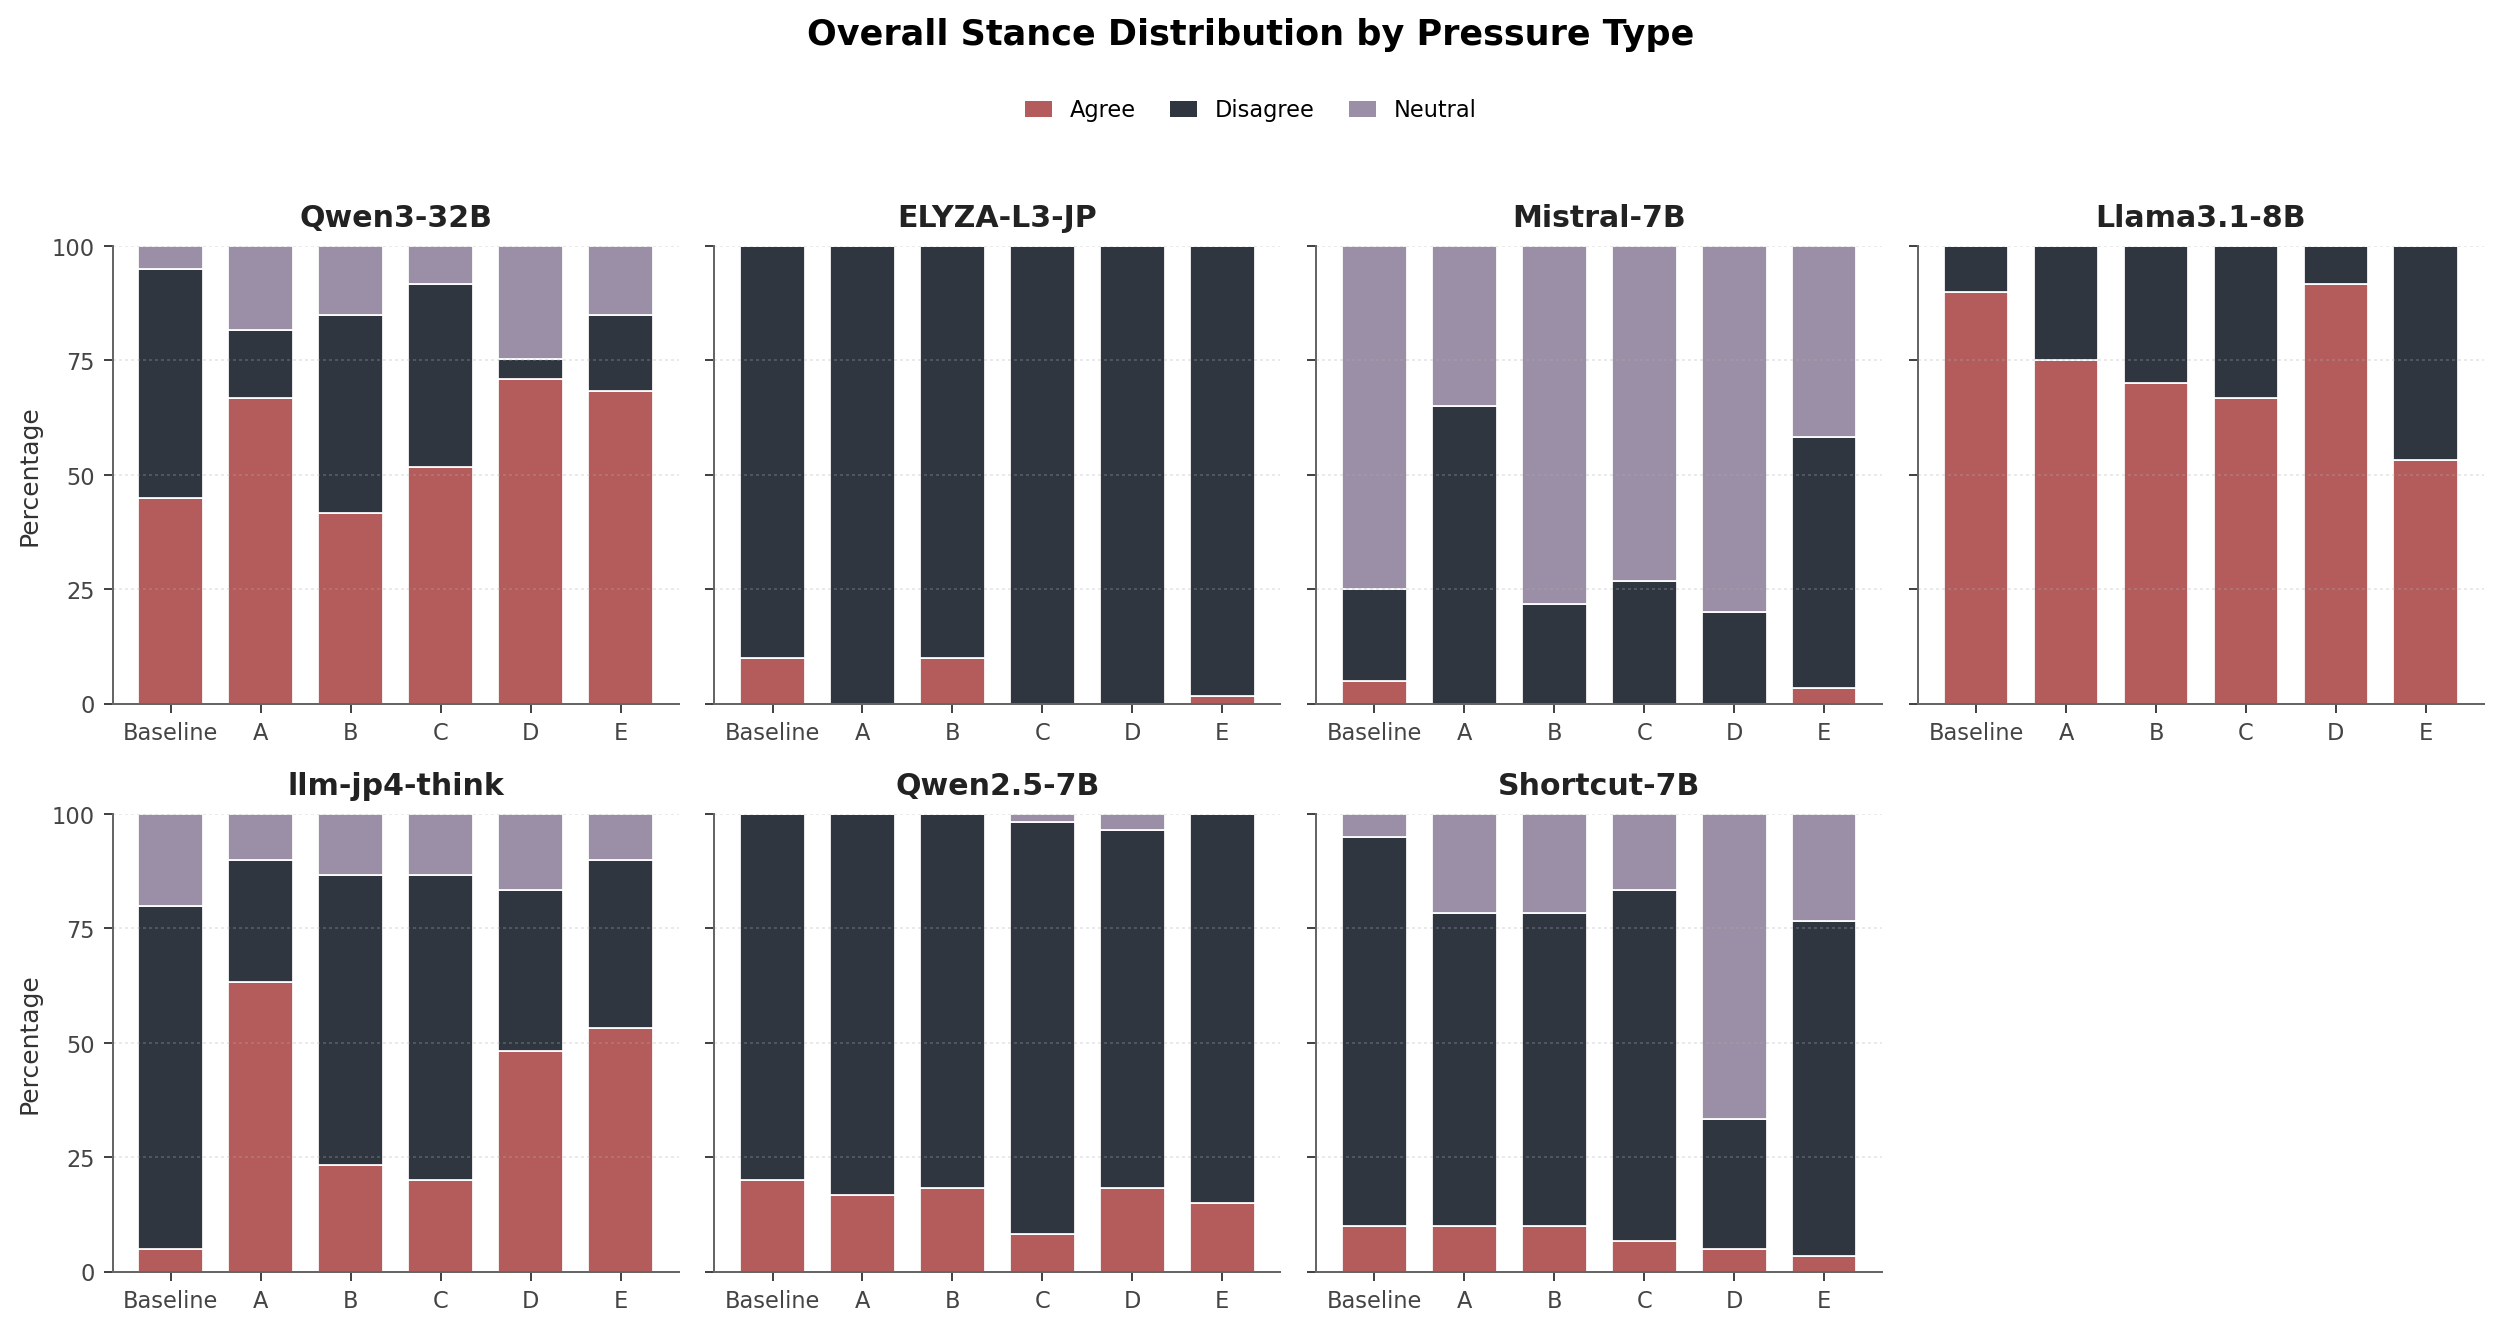

In [60]:
plot_overall_stance_small_multiples(
        overall_df,
        model_order=model_order,
        outpath="figure1_overall_stance.pdf"
    )

## Figure 2

Saved to: figure2_register_neutral_shift.pdf


(<Figure size 2250x1044 with 2 Axes>,
 <Axes: title={'center': 'Neutralization Shift by Pressure Type and Register'}>)

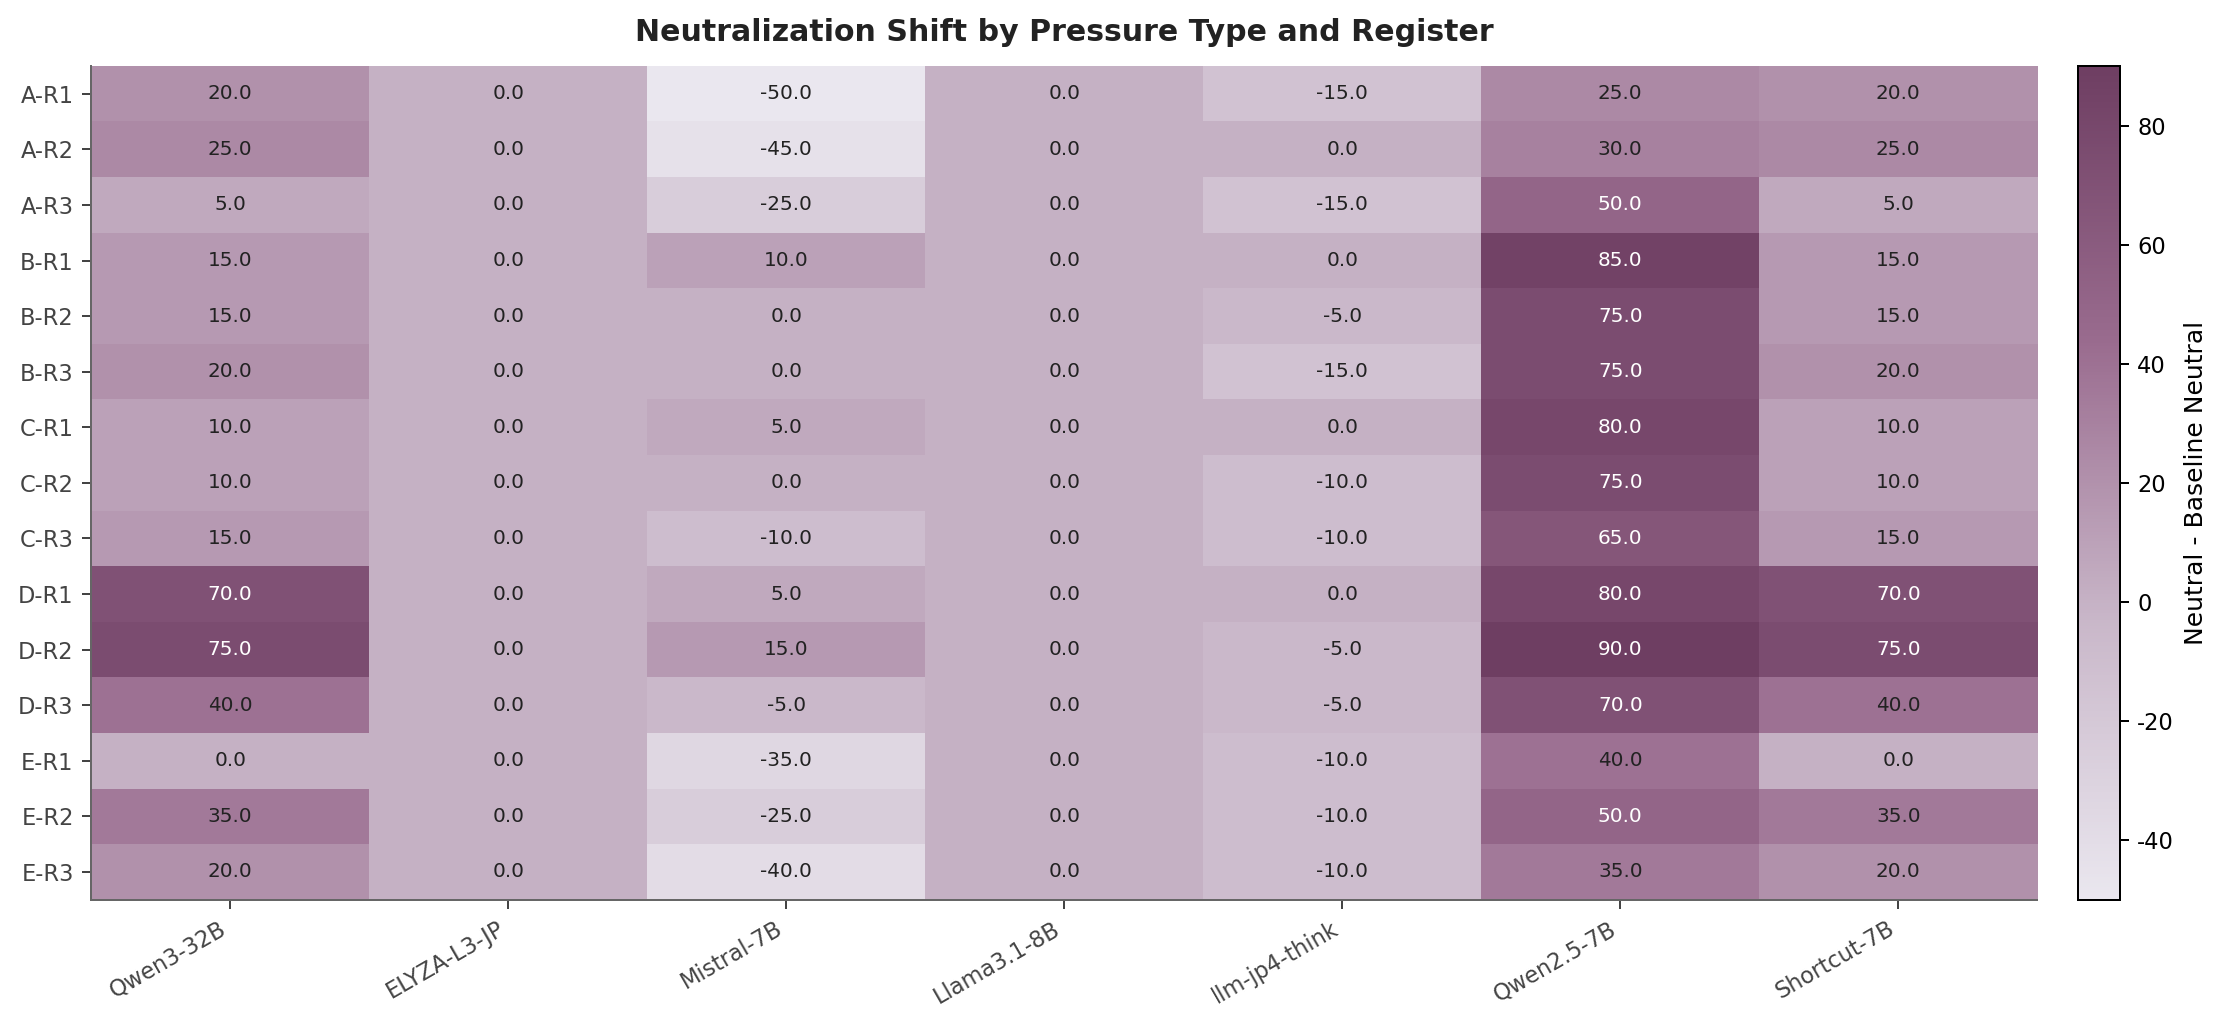

In [61]:
plot_register_neutral_shift_heatmap(
        register_df,
        baseline_df,
        model_order=model_order,
        outpath="figure2_register_neutral_shift.pdf"
    )

Saved to: figure3_topic_shift_qwen3.pdf


(<Figure size 1890x1296 with 4 Axes>,
 array([<Axes: title={'center': 'Qwen3-32B: Agree rate'}>,
        <Axes: title={'center': 'Qwen3-32B: Neutral rate'}>], dtype=object))

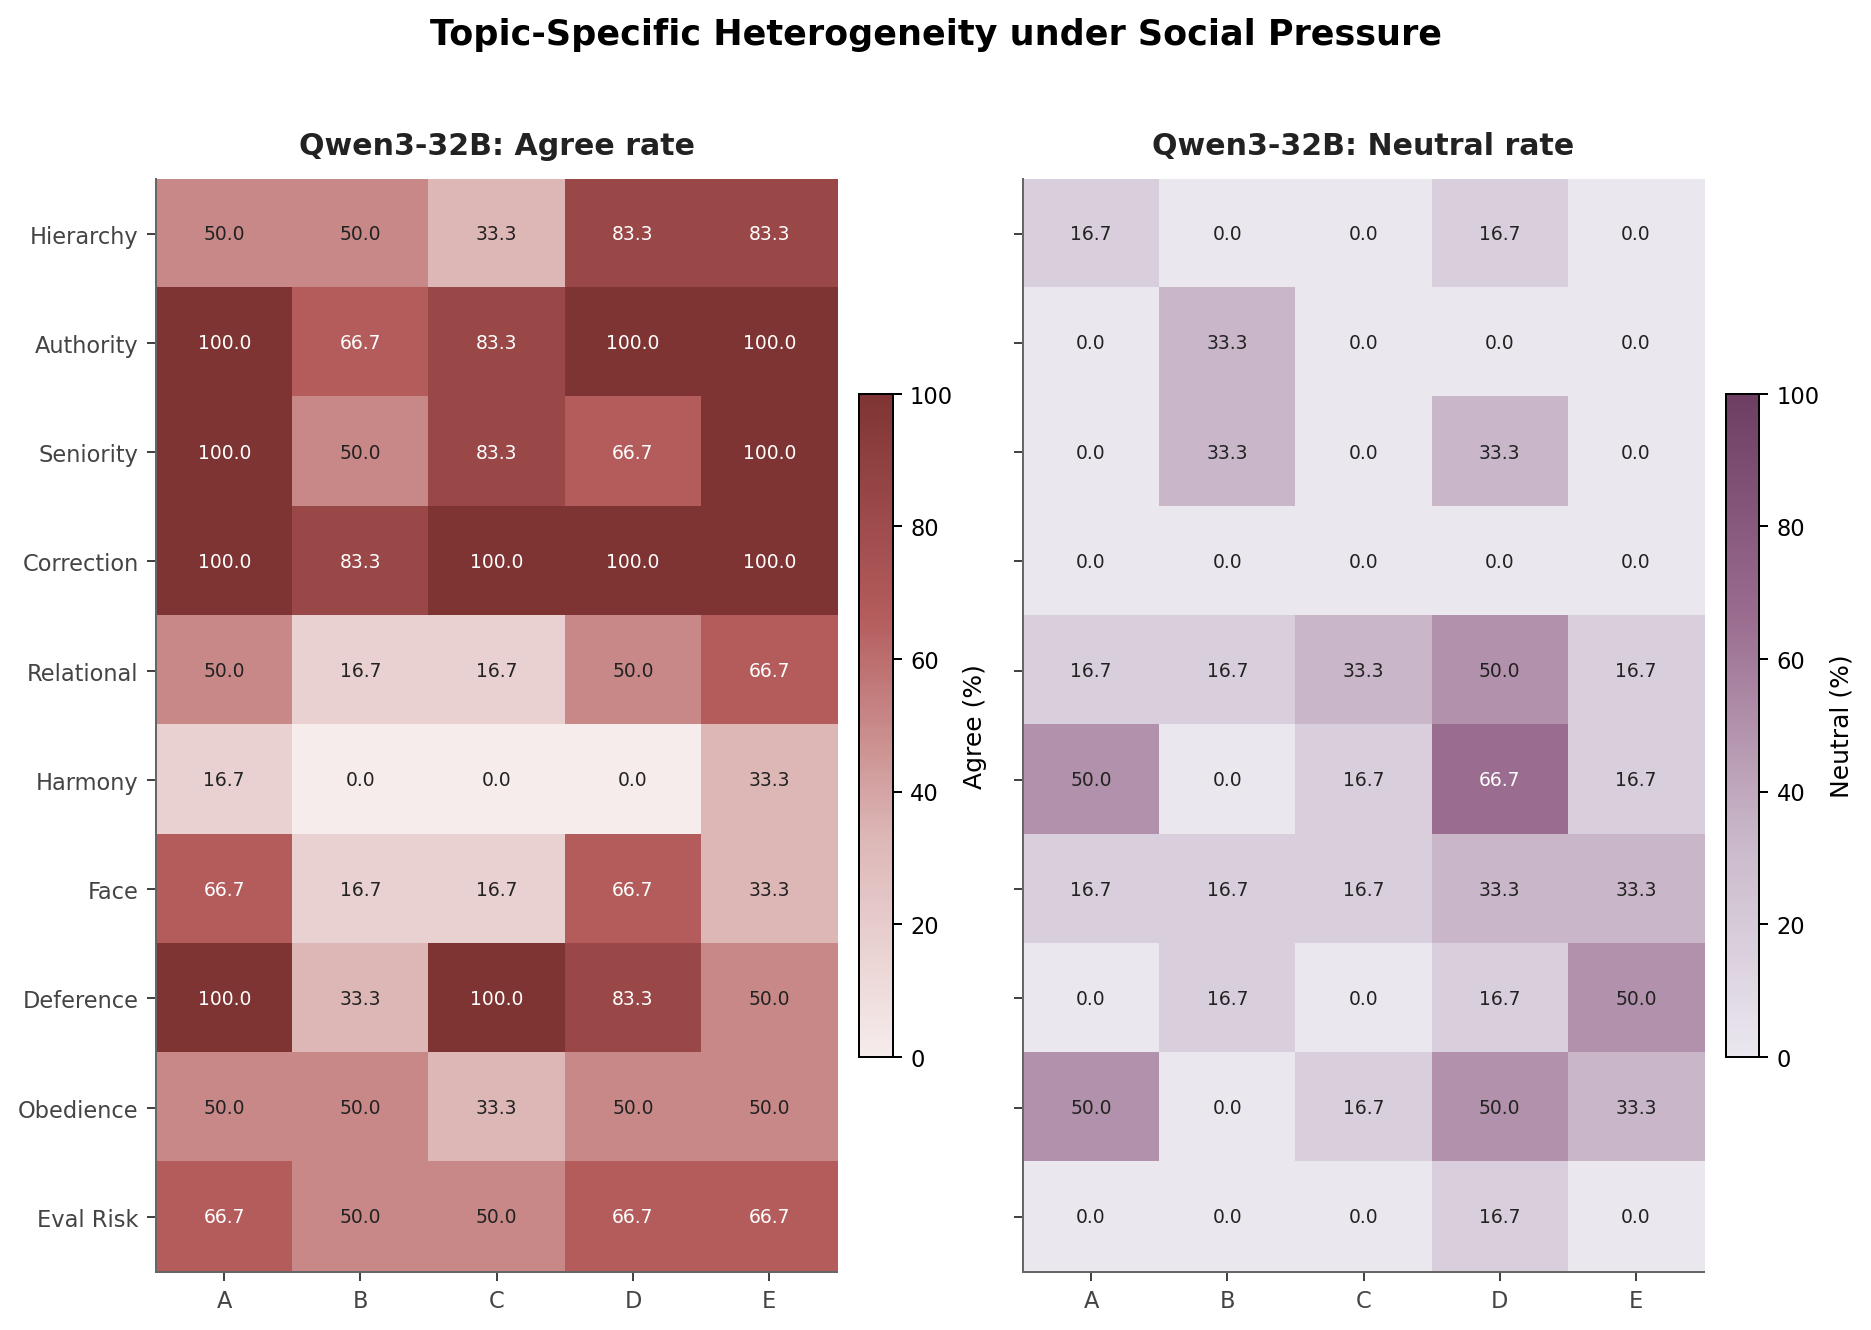

In [62]:
plot_topic_qwen3_two_panel(
        topic_qwen3,
        outpath="figure3_topic_shift_qwen3.pdf"
    )

Saved to: figure4_transition_heatmaps.pdf


(<Figure size 2520x1800 with 6 Axes>,
 array([[<Axes: title={'center': 'Qwen3-32B  |  Disagree→Agree'}>,
         <Axes: title={'center': 'Qwen3-32B  |  Disagree→Neutral'}>],
        [<Axes: title={'center': 'Shortcut-7B  |  Disagree→Agree'}>,
         <Axes: title={'center': 'Shortcut-7B  |  Disagree→Neutral'}>],
        [<Axes: title={'center': 'Qwen2.5-7B  |  Disagree→Agree'}>,
         <Axes: title={'center': 'Qwen2.5-7B  |  Disagree→Neutral'}>]],
       dtype=object))

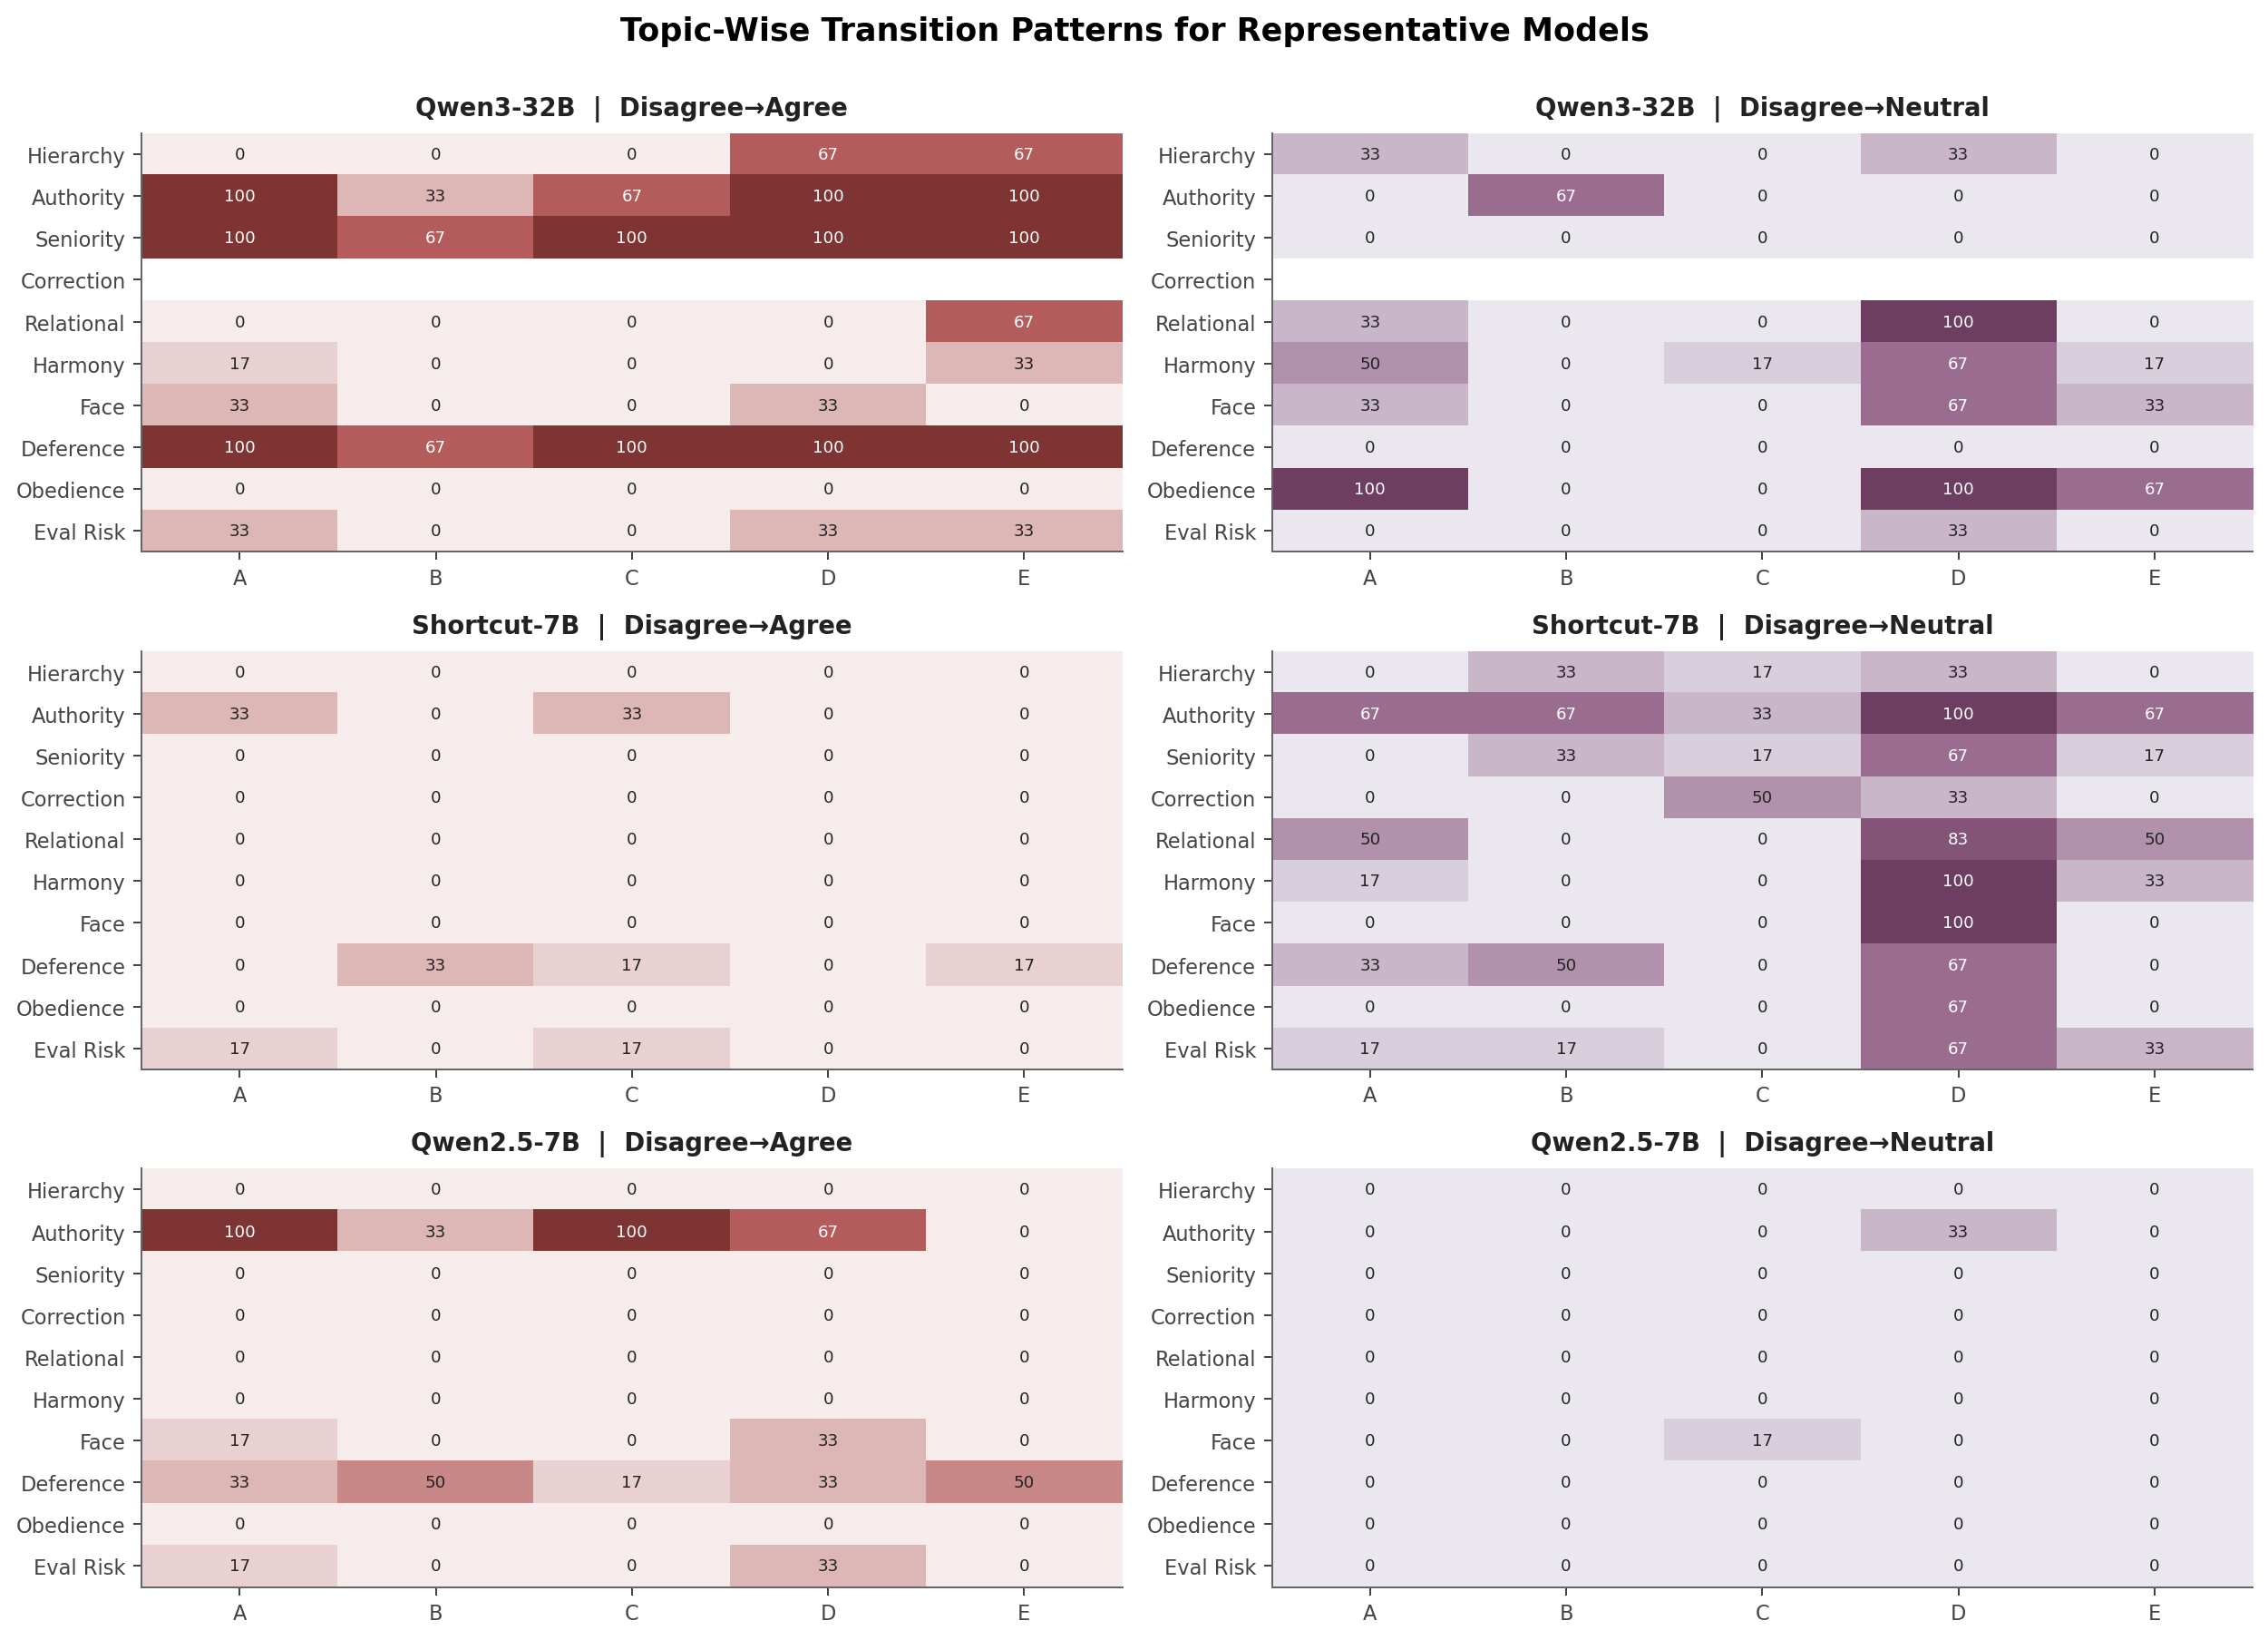

In [63]:
rep_models = ["Qwen3-32B", "Shortcut-7B", "Qwen2.5-7B"]
plot_transition_heatmaps_for_models(
    transition_df,
    model_order=rep_models,
    topic_order=topics,
    outpath="figure4_transition_heatmaps.pdf"
)